# Decision tree classifier

## Heart Disease prediction

In [1]:
# import all necesarry libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# loading the data
df = pd.read_csv("/content/drive/MyDrive/heart.csv")
df.head()

,Unnamed: 0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## Data Cleaning

In [3]:
# removing unwanted columns
df=df.drop("Unnamed: 0",axis=1)
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


# EDA

<Axes: xlabel='age', ylabel='Count'>

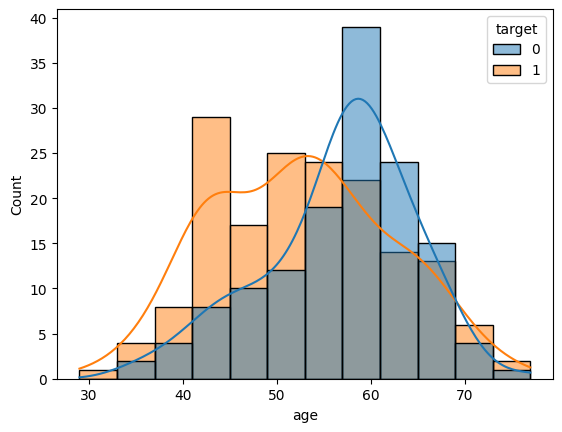

In [6]:
sns.histplot(x="age",data=df,kde=True,hue="target")

<Axes: xlabel='chol', ylabel='Count'>

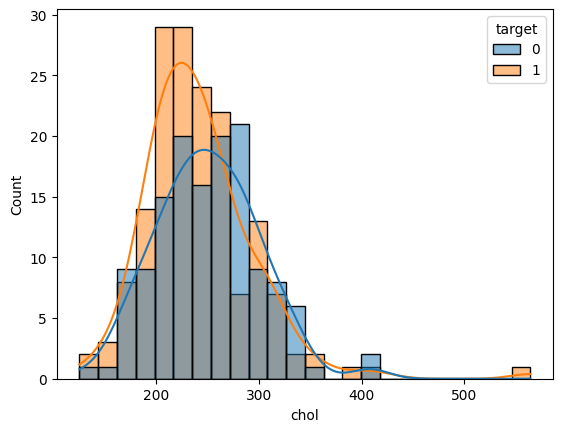

In [5]:
sns.histplot(x="chol",data=df,kde=True,hue="target")

<Axes: xlabel='trestbps', ylabel='Count'>

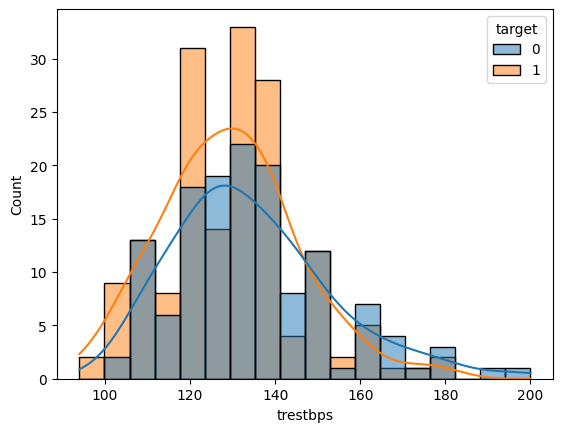

In [4]:
sns.histplot(x="trestbps",data=df,kde=True,hue="target")

# Model Training

In [7]:
# Dividing data into input and output
X = df.drop("target",axis=1)
y = df["target"]

In [8]:
# splitting the data for training and testing
Xtrain,Xtest,ytrain,ytest = train_test_split(X,y,test_size=0.3,random_state=42)

In [11]:
# model training
model = DecisionTreeClassifier(max_depth=3)
model.fit(Xtrain,ytrain)

DecisionTreeClassifier(max_depth=3)

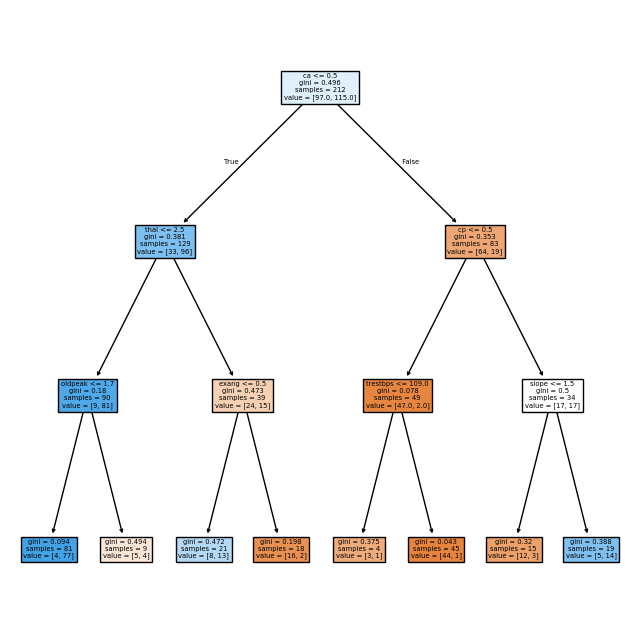

In [13]:
# Tree visualization
from sklearn.tree import plot_tree
plt.figure(figsize=(8,8))
plot_tree(model,feature_names=df.columns[:-1],filled=True)
plt.show()

## Model evaluation

In [14]:
# prediction
ypred = model.predict(Xtest)
ypred

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 1])

In [15]:
confusion_matrix(ytest,ypred)

array([[32,  9],
       [12, 38]])

In [17]:
# performance metrics
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.73      0.78      0.75        41
           1       0.81      0.76      0.78        50

    accuracy                           0.77        91
   macro avg       0.77      0.77      0.77        91
weighted avg       0.77      0.77      0.77        91



In [18]:
# Efficiency
print("Training Eff: ",model.score(Xtrain,ytrain))
print("Testing Eff: ",model.score(Xtest,ytest))

Training Eff:  0.8679245283018868
Testing Eff:  0.7692307692307693


In [19]:
# New input
new_data=df.iloc[0:1,:-1]
pred = model.predict(new_data)
prob = model.predict_proba(new_data)
if pred==0:
  print("no sign of heart disease")
else:
  print("sign of heart disease")
print("Probability: ",prob)

no sign of heart disease
Probability:  [[0.55555556 0.44444444]]
